# Return Simulation Analysis
In the real world, return flags are tracked by the logistics system. Since Olist didn't provide return data, i built a complex, stochastic SQL simulation to generate a highly realistic `is_returned` flag based on business logic (late deliveries, bad reviews, high freight costs).

In this notebook, i isolate that target variable and visually validate our logic to ensure the Machine Learning algorithms have a solid foundation to learn from.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as mtick

In [2]:
data_dir = '../data/sql_outputs/'
orders_df = pd.read_csv(os.path.join(data_dir, 'order_features_with_returns.csv'))

### The Class Imbalance

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25208\1337451678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=orders_df, x='is_returned', palette=['#2ecc71', '#e74c3c'])


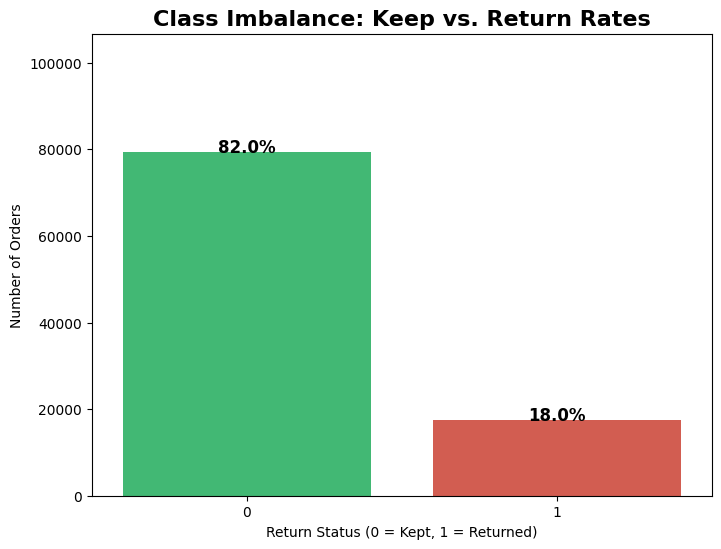

In [3]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=orders_df, x='is_returned', palette=['#2ecc71', '#e74c3c'])
plt.title('Class Imbalance: Keep vs. Return Rates', fontsize=16, fontweight='bold')
plt.xlabel('Return Status (0 = Kept, 1 = Returned)')
plt.ylabel('Number of Orders')

total = len(orders_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 1000),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black')

plt.ylim(0, total * 1.1)
plt.show()

**Conclusion:** We have a massive Class Imbalance. If a model simply guesses "0" every time, it will be 87% accurate, but entirely useless for the business. This justifies why we cannot use standard Accuracy as a metric, and must rely on **F1-Scores** and **ROC-AUC** during the Machine Learning phase.

### Return Rates by Product Category

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25208\3308111368.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_returns.values * 100, y=cat_returns.index, palette='Reds_r')


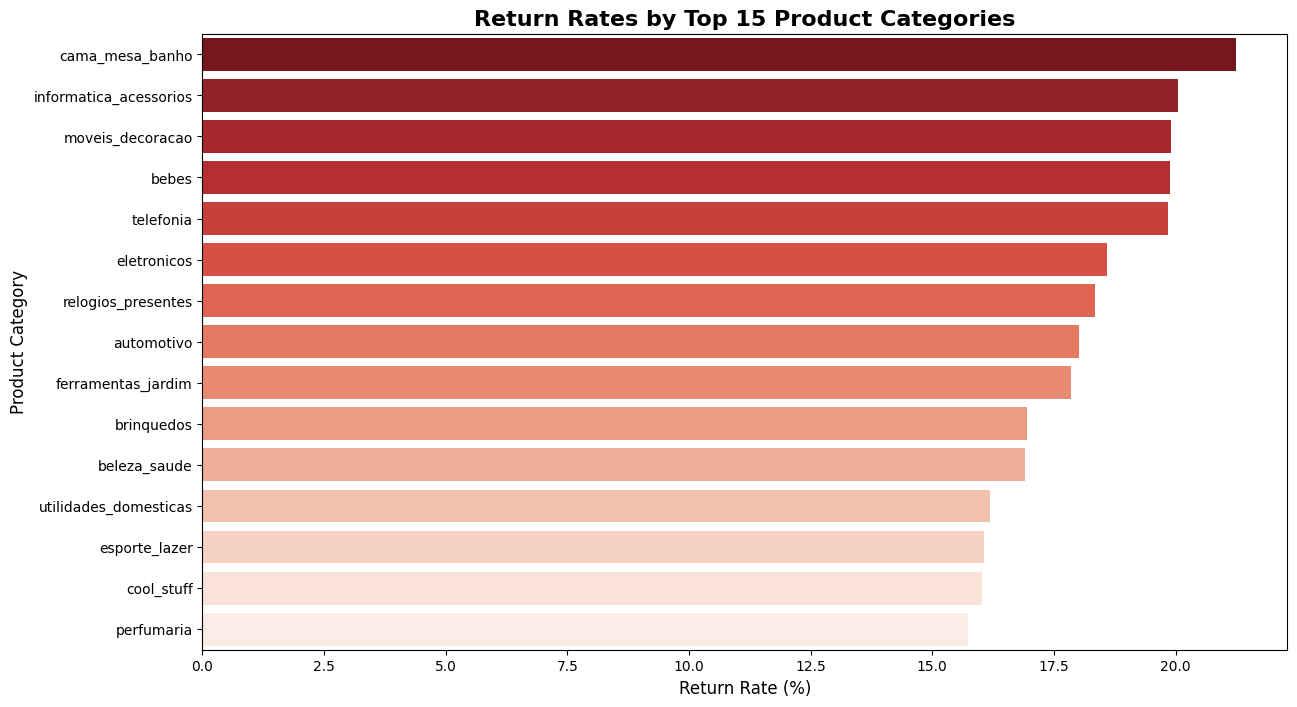

In [4]:
plt.figure(figsize=(14, 8))

top_cats = orders_df['product_category'].value_counts().nlargest(15).index
cat_returns = orders_df[orders_df['product_category'].isin(top_cats)].groupby('product_category')['is_returned'].mean().sort_values(ascending=False)

sns.barplot(x=cat_returns.values * 100, y=cat_returns.index, palette='Reds_r')
plt.title('Return Rates by Top 15 Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Return Rate (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.show()

- **Insight:** Heavy or technical categories (like Office Furniture and Computers) show drastically higher return rates compared to common household items (like Housewares or Toys).

### Validating the Jitter Logic (Return Rate vs Review Score)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25208\2052471474.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=review_returns, x='review_score', y='is_returned', palette='RdYlGn')


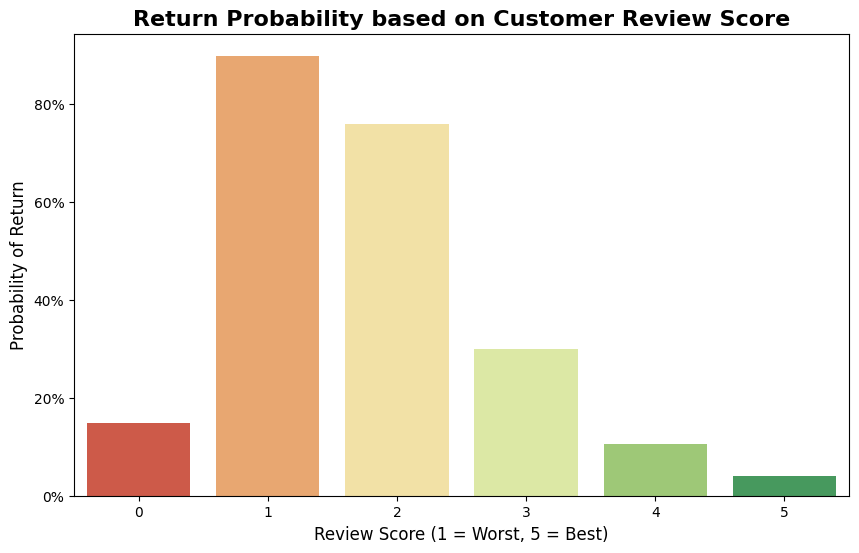

In [5]:
plt.figure(figsize=(10, 6))
review_returns = orders_df.groupby('review_score')['is_returned'].mean().reset_index()

ax = sns.barplot(data=review_returns, x='review_score', y='is_returned', palette='RdYlGn')
plt.title('Return Probability based on Customer Review Score', fontsize=16, fontweight='bold')
plt.xlabel('Review Score (1 = Worst, 5 = Best)', fontsize=12)
plt.ylabel('Probability of Return', fontsize=12)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

 **Insight:** The bar chart shows a beautiful, smooth curve. 1-star reviews result in a near 85%+ chance of an item being returned, while 5-star reviews sit under 5%.
- **Conclusion:** Our complex SQL stochastic simulation (`threshold + jitter`) was a massive success. Instead of hard-coded binary flags, we successfully generated realistic probabilistic data that an ML algorithm can effectively learn from.